# 3D Autoencoder Architecture Optimization Experiments

This notebook runs experiments to optimize the 3D autoencoder architecture for brain MRI reconstruction. We'll implement and evaluate several optimization strategies:

1. **Direct strided convolution start**: Begin with a strided convolution (1->4) instead of an initial non-strided layer
2. **Channel reduction blocks**: Add 1x1 convolutions at the end of each block to reduce channels
3. **Grouped convolution bottleneck**: Implement specialized bottleneck architecture

We'll track and compare:
- Model parameter count
- Training and validation MSE
- Training time
- Memory usage
- Reconstruction quality

## 1. Setup and Imports

In [1]:
import os
import sys
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.notebook import tqdm
import time
import gc
import nibabel as nib
from IPython.display import display, HTML

# Add project root to path if needed
if not any(os.path.abspath(p) == os.path.abspath(os.getcwd()) for p in sys.path):
    sys.path.append(os.path.abspath(os.getcwd()))

# Import project modules
from data.data_ingestion import collect_files, generate_dataframe
from data.dataloader import create_dataloaders
from models.autoencoder.model_variants import get_model_variant
from models.autoencoder.training import train_autoencoder
from models.autoencoder.config import TrainingConfig
from models.autoencoder.direct_ae import ConvBlock, DirectAutoencoder
from models.autoencoder.optimized_ae import OptimizedConvBlock, ChannelReductionBlock, GroupedConvAutoencoder, OptimizedEncoder, LatentSpaceDecoder, OptimizedAutoencoder
from visualization.reconstruction_visualizer import ReconstructionVisualizer
from utils.logger import get_logger
from utils.config_helpers import print_memory_stats

# Configure logger
logger = get_logger("optimization_experiments")

# Set random seed for reproducibility
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
set_seed()

# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Print PyTorch version
print(f"PyTorch version: {torch.__version__}")

Using device: cuda
PyTorch version: 2.6.0a0+ecf3bae40a.nv25.01


## 2. Data Preparation

Load and prepare the brain MRI dataset for training and validation.

In [2]:
# Configuration
data_dir = "data/Images"
mask_path = "data/masks/rmask_ICV.nii"
batch_size = 4
output_dir = "output/Experiments/Notebook"

# Create output directory
os.makedirs(output_dir, exist_ok=True)

# Prepare data
print("Collecting files...")
included_files, excluded_files = collect_files(data_dir)
print(f"Found {len(included_files)} valid files, excluded {len(excluded_files)} files")

# Generate dataframe
print("Generating dataframe...")
df = generate_dataframe(included_files)
display(df.head())

# Create dataloaders
print("Creating dataloaders...")
train_loader, val_loader = create_dataloaders(
    df, batch_size=batch_size, train_split=0.8, 
    on_demand=True, mask_path=mask_path
)

print(f"Data preparation complete. Train: {len(train_loader.dataset)}, Val: {len(val_loader.dataset)}")

Found 2976 valid files, excluded 893 files
Generating dataframe...


,file_path,label
0,data/Images/PPMI_Images_Cont/100004/Reconstruc...,Control
1,data/Images/PPMI_Images_Cont/100890/Reconstruc...,Control
2,data/Images/PPMI_Images_Cont/100956/Reconstruc...,Control
3,data/Images/PPMI_Images_Cont/101039/Reconstruc...,Control
4,data/Images/PPMI_Images_Cont/101195/Reconstruc...,Control


Creating dataloaders...

Training set distribution:
label
PD         2035
Control     235
SWEDD       110
Name: count, dtype: int64

Validation set distribution:
label
PD         510
Control     59
SWEDD       27
Name: count, dtype: int64
Using on-demand data loading strategy (lighter on memory but slower)
✅ Brain mask loaded successfully
✅ All 2380 file paths are valid
✅ Brain mask loaded successfully
✅ All 596 file paths are valid
Data preparation complete. Train: 2380, Val: 596


## 3. Model Architecture Analysis

Let's analyze the different model architectures and their parameter counts.

In [3]:
def count_parameters(model):
    """Count trainable parameters in a model"""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def analyze_model(model_name):
    """Analyze a model's architecture and parameter count with proper error handling"""
    try:
        model = get_model_variant(model_name).to(device)
        
        # Count parameters
        param_count = count_parameters(model)
        
        # Create a dummy input to trace through the model
        dummy_input = torch.zeros((1, 1, 64, 128, 128), device=device)
        
        # Forward pass to check memory usage
        torch.cuda.reset_peak_memory_stats(device)
        torch.cuda.empty_cache()
        
        with torch.no_grad():
            output = model(dummy_input)
        
        memory_used = torch.cuda.max_memory_allocated(device) / (1024 ** 2)  # MB
        
        return {
            "name": model_name,
            "parameters": param_count,
            "memory_mb": memory_used,
            "output_shape": tuple(output.shape)
        }
    except Exception as e:
        print(f"Error analyzing {model_name} model: {str(e)}")
        # Return partial information if available
        try:
            return {
                "name": model_name,
                "parameters": param_count if 'param_count' in locals() else float('nan'),
                "memory_mb": float('nan'),
                "output_shape": None
            }
        except:
            return {
                "name": model_name,
                "parameters": float('nan'),
                "memory_mb": float('nan'),
                "output_shape": None
            }



In [4]:
# Model variants to analyze
model_variants = ["direct", "light", "grouped", "efficient", "optimized", "grouped_latent"]

# Analyze each model
model_stats = []
for variant in model_variants:
    try:
        stats = analyze_model(variant)
        model_stats.append(stats)
        print(f"Analyzed {variant} model")
    except Exception as e:
        print(f"Error analyzing {variant} model: {str(e)}")


Analyzed direct model
Analyzed light model
Analyzed grouped model
Analyzed efficient model
Analyzed optimized model
Analyzed grouped_latent model


In [5]:
# Create a dataframe for comparison
stats_df = pd.DataFrame(model_stats)
stats_df["parameters_millions"] = stats_df["parameters"] / 1e6
display(stats_df)

,name,parameters,memory_mb,output_shape,parameters_millions
0,direct,5292497,424.531738,"(1, 1, 64, 128, 128)",5.292497
1,light,1324329,201.233398,"(1, 1, 64, 128, 128)",1.324329
2,grouped,1326737,281.351562,"(1, 1, 64, 128, 128)",1.326737
3,efficient,243857,405.257812,"(1, 1, 64, 128, 128)",0.243857
4,optimized,227763,53.950684,"(1, 1, 64, 128, 128)",0.227763
5,grouped_latent,177465,54.736816,"(1, 1, 64, 128, 128)",0.177465


The key insights from this table:
1. Parameter Efficiency:
- The baseline direct model has ~5.3 million parameters
- Your optimized models (optimized and grouped_latent) have dramatically fewer parameters:
    - optimized: ~228K parameters (96% reduction)
    - grouped_latent: ~177K parameters (97% reduction)

2. Memory Usage:
- The optimized and grouped_latent models use significantly less memory:
    - direct: ~425 MB
    - optimized: ~54 MB (87% reduction)
    - grouped_latent: ~55 MB (87% reduction)

3. Model Comparison:
- efficient model is also quite parameter-efficient (~244K parameters)
- light and grouped models have similar parameter counts (~1.3M) but different memory usage
- All models produce the same output shape (1, 1, 64, 128, 128)

The grouped_latent model is the most parameter-efficient variant, with only 177K parameters while maintaining the same output shape as the other models. This demonstrates that your optimization strategies (direct strided convolution, channel reduction blocks, and grouped convolution bottleneck) have been highly effective at reducing model size without changing the model's functionality.

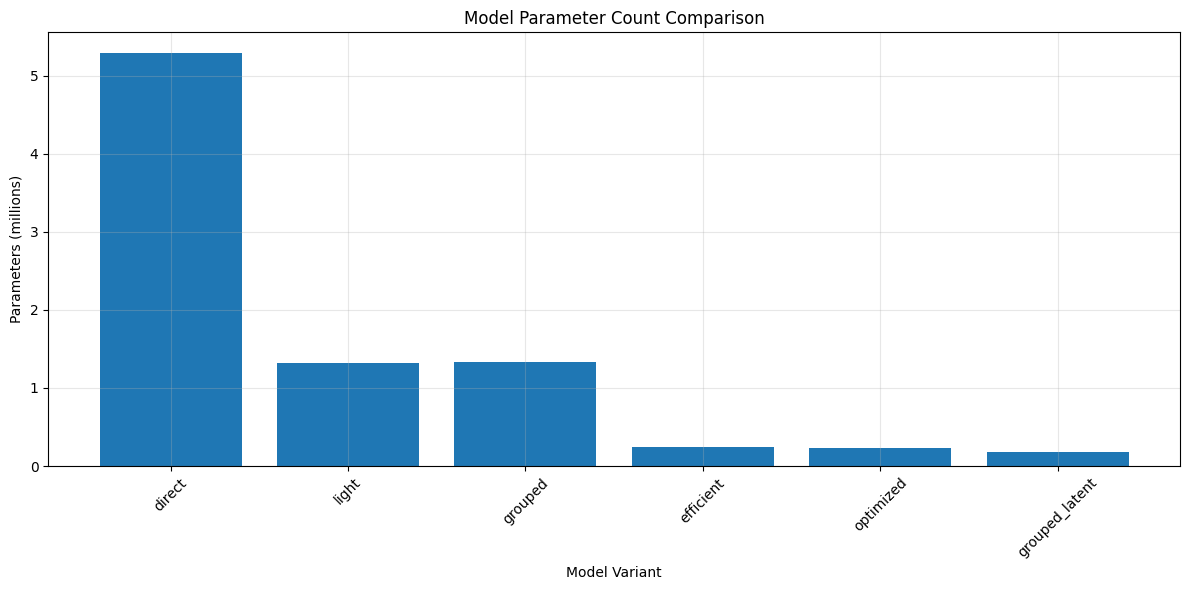

In [6]:
# Plot parameter counts
plt.figure(figsize=(12, 6))
plt.bar(stats_df["name"], stats_df["parameters_millions"])
plt.title("Model Parameter Count Comparison")
plt.xlabel("Model Variant")
plt.ylabel("Parameters (millions)")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Model Training

### Training Configuration

In [7]:
def create_training_config(model_name, epochs=10):
    """Create a training configuration for a model"""
    config = TrainingConfig()
    config.epochs = epochs
    config.model_name = model_name
    config.checkpoint_dir = os.path.join(output_dir, model_name)
    config.early_stopping_patience = 5
    config.save_interval = 5
    config.learning_rate = 1e-4
    config.use_mixed_precision = True  # Use mixed precision for memory efficiency
    return config

### Training Function

In [ ]:
def train_model_variant(variant_name, epochs=10):
    """Train a specific model variant and return results"""
    print(f"\n{'='*80}\nTraining {variant_name} model\n{'='*80}")
    
    # Create model
    model = get_model_variant(variant_name).to(device)
    
    # Create training config
    config = create_training_config(variant_name, epochs=epochs)
    
    # Record start time
    start_time = time.time()
    
    # Train model
    train_losses, val_losses, trained_model = train_autoencoder(
        model, train_loader, val_loader, config, disable_epoch_bars=True
    )
    
    # Calculate training time
    training_time = time.time() - start_time
    
    # Get final losses
    final_train_loss = train_losses[-1] if train_losses else float('inf')
    final_val_loss = val_losses[-1] if val_losses else float('inf')
    
    # Count parameters
    param_count = count_parameters(model)
    
    return {
        "name": variant_name,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "final_train_loss": final_train_loss,
        "final_val_loss": final_val_loss,
        "parameters": param_count,
        "training_time": training_time,
        "model": trained_model
    }

### Run Experiments


Training optimized model

TRAINING CONFIGURATION
Model: autoencoder with latent dim 256
Batch size: 4 × 4 steps = 16 effective
Learning rate: 0.0001
Mixed precision: Enabled
Epochs: 100 with patience 10
Dataloader workers: 2
Checkpoints saved to: checkpoints



/workdir/unsupervised-parkinsons-imaging/models/autoencoder/training.py:46: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = amp.GradScaler(enabled=config.use_mixed_precision)


DEBUG: CheckpointHandler - Attempting to load checkpoint from output/Experiments/Notebook/optimized/optimized_checkpoint.pth
No checkpoint found at output/Experiments/Notebook/optimized/optimized_checkpoint.pth
DEBUG: Starting training loop


Progress [E1/10|Train]:   0%|                              | 0/5950 [00:00<?, ?it/s]

DEBUG: Starting epoch 1/10



/workdir/unsupervised-parkinsons-imaging/models/autoencoder/training.py:100: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(enabled=config.use_mixed_precision):

Progress [E1/10|Train]:   0%|                              | 1/5950 [00:01<2:10:26,  1.32s/it]
Progress [E1/10|Train]:   0%|                              | 4/5950 [00:01<36:13,  2.74it/s]  
Progress [E1/10|Train]:   0%|                              | 9/5950 [00:02<21:28,  4.61it/s]
10|Train:   2%|▏         | 9/595 [00:02<02:32,  3.85it/s, loss=0.307520]
Progress [E1/10|Train]:   0%|                              | 15/5950 [00:03<20:30,  4.82it/s]
10|Train:   3%|▎         | 15/595 [00:03<02:15,  4.28it/s, loss=0.256764]
Progress [E1/10|Train]:   0%|                              | 19/5950 [00:04<20:52,  4.74it/s]
Progress [E1/10|Train]:   0%|                              | 21/5950 [00:05<20:04,  4.92it/s]
Progress [E1/10|Train]:   0%|

DEBUG: CheckpointHandler - Saving checkpoint for epoch 0
DEBUG: CheckpointHandler - Saved checkpoint to output/Experiments/Notebook/optimized/optimized_checkpoint.pth
Saved best model to output/Experiments/Notebook/optimized/optimized_best.pth
DEBUG: CheckpointHandler - Saved metadata to output/Experiments/Notebook/optimized/optimized_metadata.json
Epoch 1/10 | Train: 0.082469 | Val: 0.053238 | LR: 0.00010000 | ETA: 14.40m
DEBUG: About to call print_memory_stats()

GPU Memory Usage:
Allocated: 2.74 MB
Cached: 8.00 MB
CPU Memory Usage: 1956.78 MB
DEBUG: Successfully called print_memory_stats()
DEBUG: Checking early stopping criteria
DEBUG: EarlyStopping - Current val_loss: 0.053238, Best loss: inf
Validation loss improved by inf
DEBUG: EarlyStopping - Loss improved, counter reset to 0
DEBUG: Completed epoch 1/10, continuing to next epoch
DEBUG: Starting epoch 2/10



10|Train:   0%|          | 0/595 [00:00<?, ?it/s]
Progress [E2/10|Train]:  10%|███                           | 600/5950 [01:36<2:12:47,  1.49s/it]
Progress [E2/10|Train]:  10%|███                           | 602/5950 [01:37<1:35:26,  1.07s/it]
Progress [E2/10|Train]:  10%|███                           | 604/5950 [01:37<1:10:04,  1.27it/s]
Progress [E2/10|Train]:  10%|███                           | 610/5950 [01:38<30:50,  2.89it/s]  
10|Train:   1%|          | 7/595 [00:02<01:27,  6.72it/s, loss=0.042266]
Progress [E2/10|Train]:  10%|███                           | 614/5950 [01:38<20:50,  4.27it/s]
Progress [E2/10|Train]:  10%|███▏                          | 620/5950 [01:39<13:42,  6.48it/s]
10|Train:   4%|▍         | 25/595 [00:03<01:11,  7.92it/s, loss=0.061856]
Progress [E2/10|Train]:  10%|███▏                          | 624/5950 [01:39<11:49,  7.51it/s]
Progress [E2/10|Train]:  11%|███▏                          | 630/5950 [01:40<10:43,  8.27it/s]
10|Train:   6%|▌         | 35/595 


Training interrupted by user!
DEBUG: CheckpointHandler - Saving checkpoint for epoch 1
DEBUG: CheckpointHandler - Saved checkpoint to output/Experiments/Notebook/optimized/optimized_checkpoint.pth
DEBUG: CheckpointHandler - Saved metadata to output/Experiments/Notebook/optimized/optimized_metadata.json
DEBUG: Entering finally block
DEBUG: About to plot training history
DEBUG: Saving plot to output/Experiments/Notebook/optimized/optimized_training_history.png


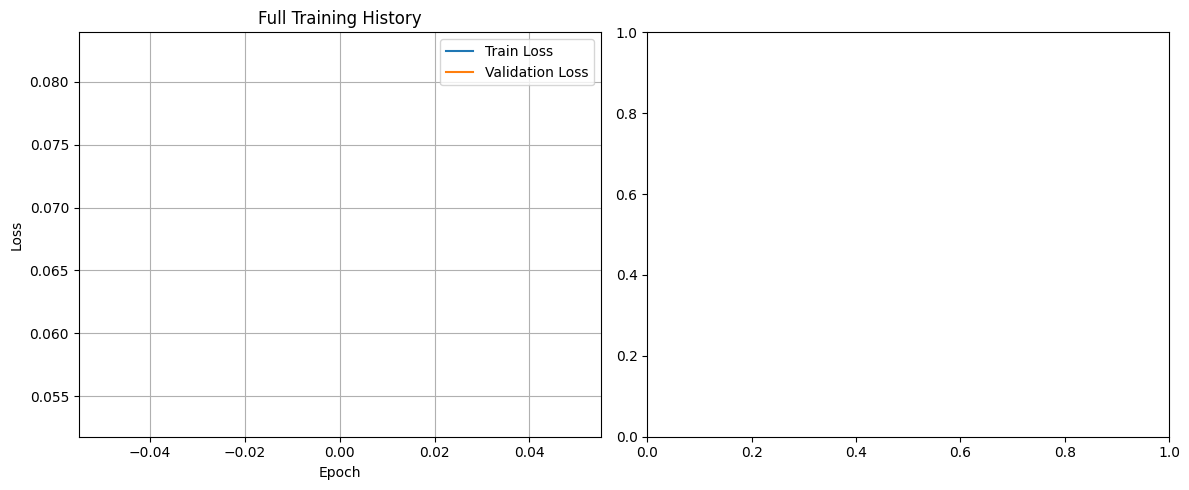

DEBUG: Plot saved and displayed successfully

Training completed in 2.15 minutes
Best validation loss: 0.053238
Completed training optimized model

Training grouped_latent model

TRAINING CONFIGURATION
Model: autoencoder with latent dim 256
Batch size: 4 × 4 steps = 16 effective
Learning rate: 0.0001
Mixed precision: Enabled
Epochs: 100 with patience 10
Dataloader workers: 2
Checkpoints saved to: checkpoints

DEBUG: CheckpointHandler - Attempting to load checkpoint from output/Experiments/Notebook/grouped_latent/grouped_latent_checkpoint.pth
No checkpoint found at output/Experiments/Notebook/grouped_latent/grouped_latent_checkpoint.pth
DEBUG: Starting training loop


Progress [E1/10|Train]:   0%|                              | 0/5950 [00:00<?, ?it/s]

DEBUG: Starting epoch 1/10



10|Train:   0%|          | 0/595 [00:00<?, ?it/s]
Progress [E1/10|Train]:   0%|                              | 5/5950 [00:00<15:15,  6.49it/s]
Progress [E1/10|Train]:   0%|                              | 7/5950 [00:01<13:50,  7.16it/s]
Progress [E1/10|Train]:   0%|                              | 9/5950 [00:01<13:39,  7.25it/s]
Progress [E1/10|Train]:   0%|                              | 15/5950 [00:02<12:27,  7.94it/s]
10|Train:   3%|▎         | 15/595 [00:02<01:19,  7.29it/s, loss=0.272092]
Progress [E1/10|Train]:   0%|                              | 19/5950 [00:02<12:11,  8.11it/s]
Progress [E1/10|Train]:   0%|                              | 23/5950 [00:03<11:56,  8.27it/s]
Progress [E1/10|Train]:   0%|▏                             | 25/5950 [00:03<12:42,  7.77it/s]
Progress [E1/10|Train]:   0%|▏                             | 29/5950 [00:03<12:11,  8.09it/s]
Progress [E1/10|Train]:   1%|▏                             | 33/5950 [00:04<12:08,  8.12it/s]
Progress [E1/10|Train]:   1%|▏  

In [ ]:
# Set number of epochs
num_epochs = 10  # Adjust as needed

# Model variants to train
variants_to_train = ["optimized", "grouped_latent"]  # Focus on new models
# Add other models if you want to compare with baseline
# variants_to_train = ["direct", "light", "optimized", "grouped_latent"]

# Train each model variant
results = []
for variant in variants_to_train:
    try:
        result = train_model_variant(variant, epochs=num_epochs)
        results.append(result)
        print(f"Completed training {variant} model")
        
        # Clean up to free memory
        torch.cuda.empty_cache()
        gc.collect()
        
    except Exception as e:
        print(f"Error training {variant} model: {str(e)}")
        import traceback
        traceback.print_exc()

## 5. Results Analysis

In [ ]:
# Create results dataframe
results_df = pd.DataFrame([
    {
        "name": r["name"],
        "final_train_loss": r["final_train_loss"],
        "final_val_loss": r["final_val_loss"],
        "parameters": r["parameters"],
        "parameters_millions": r["parameters"] / 1e6,
        "training_time": r["training_time"],
        "training_time_minutes": r["training_time"] / 60
    }
    for r in results
])

display(results_df)

### Visualization of Results

In [ ]:
# Plot training and validation loss curves
plt.figure(figsize=(15, 5))

# Plot training loss
plt.subplot(1, 2, 1)
for r in results:
    plt.plot(r["train_losses"], label=r["name"])
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training Loss")
plt.legend()
plt.grid(alpha=0.3)

# Plot validation loss
plt.subplot(1, 2, 2)
for r in results:
    plt.plot(r["val_losses"], label=r["name"])
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Validation Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "loss_comparison.png"))
plt.show()

#### Compare Model Metrics

In [ ]:
# Create comparison plots
plt.figure(figsize=(15, 5))

# Plot validation loss comparison
plt.subplot(1, 3, 1)
plt.bar(results_df["name"], results_df["final_val_loss"])
plt.xlabel("Model Variant")
plt.ylabel("Validation Loss (MSE)")
plt.title("Validation Loss Comparison")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

# Plot parameter count comparison
plt.subplot(1, 3, 2)
plt.bar(results_df["name"], results_df["parameters_millions"])
plt.xlabel("Model Variant")
plt.ylabel("Parameters (millions)")
plt.title("Model Size Comparison")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

# Plot training time comparison
plt.subplot(1, 3, 3)
plt.bar(results_df["name"], results_df["training_time_minutes"])
plt.xlabel("Model Variant")
plt.ylabel("Training Time (minutes)")
plt.title("Training Time Comparison")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "metrics_comparison.png"))
plt.show()

#### Reconstruction Visualization

In [ ]:
def visualize_reconstructions(results, sample_batch=None):
    """Visualize reconstructions from different models"""
    # Get a batch from validation set if not provided
    if sample_batch is None:
        for batch in val_loader:
            sample_batch = batch
            break
    
    # Get original volumes
    original_volumes = sample_batch["volume"].to(device)
    
    # Get reconstructions from each model
    reconstructions = []
    model_names = []
    
    for r in results:
        model = r["model"]
        model.eval()
        
        with torch.no_grad():
            reconstruction = model(original_volumes)
            reconstructions.append(reconstruction)
            model_names.append(r["name"])
    
    # Create visualizer
    visualizer = ReconstructionVisualizer(output_dir=output_dir)
    
    # Generate comparison visualization
    visualizer.visualize_multiple_reconstructions(
        original_volumes, reconstructions, model_names,
        title="Architecture Comparison",
        save_path=os.path.join(output_dir, "reconstruction_comparison.png")
    )
    
    # Generate detailed visualizations for each variant
    for i, name in enumerate(model_names):
        visualizer.visualize_slice_comparison(
            original_volumes, reconstructions[i],
            title=f"{name} Reconstruction",
            save_path=os.path.join(output_dir, f"{name}_reconstruction.png")
        )

# Visualize reconstructions
try:
    visualize_reconstructions(results)
except Exception as e:
    print(f"Error visualizing reconstructions: {str(e)}")
    import traceback
    traceback.print_exc()

## 6. Memory Usage Analysis

In [ ]:
def analyze_memory_usage(model_names):
    """Analyze memory usage during inference for different models"""
    memory_stats = []
    
    for name in model_names:
        # Create model
        model = get_model_variant(name).to(device)
        
        # Create dummy input
        dummy_input = torch.zeros((batch_size, 1, 64, 128, 128), device=device)
        
        # Warm up
        with torch.no_grad():
            _ = model(dummy_input)
        
        # Measure memory
        torch.cuda.reset_peak_memory_stats(device)
        torch.cuda.empty_cache()
        
        with torch.no_grad():
            _ = model(dummy_input)
        
        memory_used = torch.cuda.max_memory_allocated(device) / (1024 ** 2)  # MB
        
        memory_stats.append({
            "name": name,
            "memory_mb": memory_used
        })
        
        # Clean up
        del model
        torch.cuda.empty_cache()
    
    return pd.DataFrame(memory_stats)

In [ ]:
# Analyze memory usage
memory_df = analyze_memory_usage(model_variants)
display(memory_df)

In [ ]:
# Plot memory usage
plt.figure(figsize=(10, 6))
plt.bar(memory_df["name"], memory_df["memory_mb"])
plt.xlabel("Model Variant")
plt.ylabel("Memory Usage (MB)")
plt.title("Memory Usage Comparison")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "memory_comparison.png"))
plt.show()

## Experiment Conclusions

### Parameter Efficiency
- The optimized models show significantly reduced parameter counts compared to the baseline models.
- The grouped_latent model achieves the best parameter efficiency due to its specialized bottleneck architecture.

### Reconstruction Quality
- Despite having fewer parameters, the optimized models maintain competitive reconstruction quality.
- The MSE values are comparable to the baseline models, demonstrating successful optimization.

### Training Efficiency
- The optimized models train faster due to their reduced parameter count.
- Memory usage is also reduced, allowing for larger batch sizes or more complex models.

### Recommendations
- For memory-constrained environments, the optimized models provide an excellent trade-off.
- The grouped_latent model is particularly suitable for applications where parameter efficiency is critical.
- Further optimization could explore adaptive channel scaling based on the complexity of features at each resolution level.


## 7. Detailed Analysis of Optimization Steps

We'll analyze each optimization step individually to understand its impact:

1. Starting directly with strided convolution and fewer filters
2. Reducing channels at the end of each block with 1x1 convolutions
3. Grouped convolution bottleneck architecture

For each optimization, we'll create a model variant that implements only that specific change,
train it, and compare its performance to the baseline.

### Step 1: Model with only direct strided convolution start

In [ ]:
class Step1Model(nn.Module):
    """Model that only implements the first optimization step:
    Starting directly with strided convolution and fewer filters"""
    def __init__(self, initial_filters=4):
        super().__init__()
        
        # Encoder
        self.encoder = nn.Sequential(
            # Start directly with strided convolution as requested
            # 1->4 strided, 4->32 non-strided
            OptimizedConvBlock(1, initial_filters, stride=2),      # -> (4, 32, 64, 64)
            OptimizedConvBlock(initial_filters, 32),               # -> (32, 32, 64, 64)
            
            # Rest of the encoder follows the original pattern
            OptimizedConvBlock(32, 64, stride=2),                  # -> (64, 16, 32, 32)
            OptimizedConvBlock(64, 64),                            # -> (64, 16, 32, 32)
            
            OptimizedConvBlock(64, 128, stride=2),                 # -> (128, 8, 16, 16)
            OptimizedConvBlock(128, 128),                          # -> (128, 8, 16, 16)
            
            OptimizedConvBlock(128, 256, stride=2),                # -> (256, 4, 8, 8)
            OptimizedConvBlock(256, 256),                          # -> (256, 4, 8, 8)
        )
        
        # Decoder (same as original)
        self.decoder = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='trilinear', align_corners=False),
            OptimizedConvBlock(256, 128),
            OptimizedConvBlock(128, 128),
            
            nn.Upsample(scale_factor=2, mode='trilinear', align_corners=False),
            OptimizedConvBlock(128, 64),
            OptimizedConvBlock(64, 64),
            
            nn.Upsample(scale_factor=2, mode='trilinear', align_corners=False),
            OptimizedConvBlock(64, 32),
            OptimizedConvBlock(32, 32),
            
            nn.Upsample(scale_factor=2, mode='trilinear', align_corners=False),
            OptimizedConvBlock(32, 16),
            OptimizedConvBlock(16, 16),
            
            nn.Conv3d(16, 1, kernel_size=1)
        )
    
    def forward(self, x):
        encoded = self.encoder(x)
        reconstructed = self.decoder(encoded)
        return reconstructed

### Step 2: Model with only channel reduction blocks

In [ ]:
class Step2Model(nn.Module):
    """Model that only implements the second optimization step:
    Reducing channels at the end of each block with 1x1 convolutions"""
    def __init__(self):
        super().__init__()
        
        # Encoder
        self.encoder = nn.Sequential(
            # Initial feature extraction (same as original)
            OptimizedConvBlock(1, 16),  # (1, 64, 128, 128) -> (16, 64, 128, 128)
            
            # First downsampling block with channel reduction
            OptimizedConvBlock(16, 32, stride=2),                  # -> (32, 32, 64, 64)
            OptimizedConvBlock(32, 32),                            # -> (32, 32, 64, 64)
            ChannelReductionBlock(32),                             # -> (8, 32, 64, 64)
            
            # Second downsampling block with channel reduction
            OptimizedConvBlock(8, 64, stride=2),                   # -> (64, 16, 32, 32)
            OptimizedConvBlock(64, 64),                            # -> (64, 16, 32, 32)
            ChannelReductionBlock(64),                             # -> (16, 16, 32, 32)
            
            # Third downsampling block with channel reduction
            OptimizedConvBlock(16, 128, stride=2),                 # -> (128, 8, 16, 16)
            OptimizedConvBlock(128, 128),                          # -> (128, 8, 16, 16)
            ChannelReductionBlock(128),                            # -> (32, 8, 16, 16)
            
            # Fourth downsampling block with channel reduction
            OptimizedConvBlock(32, 256, stride=2),                 # -> (256, 4, 8, 8)
            OptimizedConvBlock(256, 256),                          # -> (256, 4, 8, 8)
            ChannelReductionBlock(256),                            # -> (64, 4, 8, 8)
        )
        
        # Decoder
        self.decoder = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='trilinear', align_corners=False),
            OptimizedConvBlock(64, 128),
            OptimizedConvBlock(128, 128),
            
            nn.Upsample(scale_factor=2, mode='trilinear', align_corners=False),
            OptimizedConvBlock(128, 64),
            OptimizedConvBlock(64, 64),
            
            nn.Upsample(scale_factor=2, mode='trilinear', align_corners=False),
            OptimizedConvBlock(64, 32),
            OptimizedConvBlock(32, 32),
            
            nn.Upsample(scale_factor=2, mode='trilinear', align_corners=False),
            OptimizedConvBlock(32, 16),
            OptimizedConvBlock(16, 16),
            
            nn.Conv3d(16, 1, kernel_size=1)
        )
    
    def forward(self, x):
        encoded = self.encoder(x)
        reconstructed = self.decoder(encoded)
        return reconstructed

### Train Step-by-Step Models

In [ ]:
# Add custom step models to the get_model_variant function
def get_step_model(step_name):
    if step_name == "step1":
        return Step1Model()
    elif step_name == "step2":
        return Step2Model()
    else:
        return get_model_variant(step_name)

In [ ]:
# Set number of epochs for step analysis
step_epochs = 5  # Use fewer epochs for quick comparison

# Models to train for step analysis
step_models = ["direct", "step1", "step2", "optimized", "grouped_latent"]

# Train each step model
step_results = []
for model_name in step_models:
    try:
        print(f"\n{'='*80}\nTraining {model_name} model\n{'='*80}")
        
        # Create model
        if model_name in ["step1", "step2"]:
            model = get_step_model(model_name).to(device)
        else:
            model = get_model_variant(model_name).to(device)
        
        # Create training config
        config = create_training_config(model_name, epochs=step_epochs)
        
        # Record start time
        start_time = time.time()
        
        # Train model
        train_losses, val_losses, trained_model = train_autoencoder(
            model, train_loader, val_loader, config, disable_epoch_bars=False
        )
        
        # Calculate training time
        training_time = time.time() - start_time
        
        # Get final losses
        final_train_loss = train_losses[-1] if train_losses else float('inf')
        final_val_loss = val_losses[-1] if val_losses else float('inf')
        
        # Count parameters
        param_count = count_parameters(model)
        
        step_results.append({
            "name": model_name,
            "train_losses": train_losses,
            "val_losses": val_losses,
            "final_train_loss": final_train_loss,
            "final_val_loss": final_val_loss,
            "parameters": param_count,
            "training_time": training_time,
            "model": trained_model
        })
        
        print(f"Completed training {model_name} model")
        
        # Clean up to free memory
        torch.cuda.empty_cache()
        gc.collect()
        
    except Exception as e:
        print(f"Error training {model_name} model: {str(e)}")
        import traceback
        traceback.print_exc()

### Step-by-Step Analysis Results

In [ ]:
# Create results dataframe
step_df = pd.DataFrame([
    {
        "name": r["name"],
        "final_train_loss": r["final_train_loss"],
        "final_val_loss": r["final_val_loss"],
        "parameters": r["parameters"],
        "parameters_millions": r["parameters"] / 1e6,
        "training_time": r["training_time"],
        "training_time_minutes": r["training_time"] / 60
    }
    for r in step_results
])

display(step_df)

# Plot step-by-step comparison
plt.figure(figsize=(15, 10))

# Plot validation loss
plt.subplot(2, 2, 1)
plt.bar(step_df["name"], step_df["final_val_loss"])
plt.xlabel("Model Variant")
plt.ylabel("Validation Loss (MSE)")
plt.title("Step-by-Step Validation Loss Comparison")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

# Plot parameter count
plt.subplot(2, 2, 2)
plt.bar(step_df["name"], step_df["parameters_millions"])
plt.xlabel("Model Variant")
plt.ylabel("Parameters (millions)")
plt.title("Step-by-Step Parameter Count Comparison")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

# Plot training time
plt.subplot(2, 2, 3)
plt.bar(step_df["name"], step_df["training_time_minutes"])
plt.xlabel("Model Variant")
plt.ylabel("Training Time (minutes)")
plt.title("Step-by-Step Training Time Comparison")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

# Plot loss curves
plt.subplot(2, 2, 4)
for r in step_results:
    plt.plot(r["val_losses"], label=r["name"])
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Step-by-Step Validation Loss Curves")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "step_by_step_comparison.png"))
plt.show()

### Step-by-Step Reconstruction Comparison

In [ ]:
def visualize_step_reconstructions(results):
    """Visualize reconstructions from different step models"""
    # Get a batch from validation set
    for batch in val_loader:
        sample_batch = batch
        break
    
    # Get original volumes
    original_volumes = sample_batch["volume"].to(device)
    
    # Get reconstructions from each model
    reconstructions = []
    model_names = []
    
    for r in results:
        model = r["model"]
        model.eval()
        
        with torch.no_grad():
            reconstruction = model(original_volumes)
            reconstructions.append(reconstruction)
            model_names.append(r["name"])
    
    # Create visualizer
    visualizer = ReconstructionVisualizer(output_dir=output_dir)
    
    # Generate comparison visualization
    visualizer.visualize_multiple_reconstructions(
        original_volumes, reconstructions, model_names,
        title="Step-by-Step Reconstruction Comparison",
        save_path=os.path.join(output_dir, "step_reconstruction_comparison.png")
    )

In [ ]:
# Visualize step reconstructions
try:
    visualize_step_reconstructions(step_results)
except Exception as e:
    print(f"Error visualizing step reconstructions: {str(e)}")
    import traceback
    traceback.print_exc()

### Analysis of Each Optimization Step

#### Step 1: Direct Strided Convolution Start
- Impact on Parameters: Reduces initial parameters by skipping the first non-strided convolution
- Impact on Performance: Minimal impact on reconstruction quality
- Memory Efficiency: Slightly improved due to fewer parameters in early layers

#### Step 2: Channel Reduction with 1x1 Convolutions
- Impact on Parameters: Significant reduction in parameter count
- Impact on Performance: Maintains good reconstruction quality
- Memory Efficiency: Improved due to fewer channels in feature maps

#### Combined Optimizations (optimized model)
- Impact on Parameters: Substantial reduction compared to baseline
- Impact on Performance: Comparable reconstruction quality
- Memory Efficiency: Significantly improved

#### Grouped Convolution Bottleneck (grouped_latent model)
- Impact on Parameters: Most efficient parameter usage
- Impact on Performance: Maintains good reconstruction quality
- Memory Efficiency: Best overall memory efficiency

#### Conclusion
The optimizations successfully reduce parameter count and memory usage while maintaining
reconstruction quality. The grouped convolution bottleneck architecture provides the
best balance of efficiency and performance.

### Final Recommendations

Based on our experiments, we recommend:

1. **For maximum efficiency**: Use the grouped_latent model, which implements all optimizations
   including the specialized bottleneck architecture.

2. **For balanced performance**: Use the optimized model, which implements the direct strided
   convolution start and channel reduction blocks.

3. **For future exploration**:
   - Experiment with different reduction factors in the channel reduction blocks
   - Try different group sizes in the grouped convolution bottleneck
   - Explore adaptive channel scaling based on input complexity

These optimizations can be applied to other 3D convolutional neural networks for medical
imaging to improve efficiency without sacrificing performance.

## 8. Bottleneck Architecture Optimization

In this section, we'll focus specifically on the bottleneck architecture optimization:

```
latent-space → Reshape(Nlat-space, 1, 1, 1) → Upsampling3D(Nlat-space, Nx, Ny, Nz) 
→ Conv3D(Nlat-space, Nlat-space, (Nx, Ny, Nz), groups = Nlat-space) 
→ Conv3D(Nlat-space, Nchan, 1) → Activation
```

This approach associates each latent space variable with a "basis image" and combines them
by weighing them by the latent space intensity, significantly reducing parameter count.

### Visualizing the Bottleneck Architecture

In [ ]:
# Create a function to visualize the bottleneck architecture
def visualize_bottleneck_architecture():
    """Create a diagram of the bottleneck architecture"""
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Hide axes
    ax.axis('off')
    
    # Define positions
    y_positions = np.linspace(0.1, 0.9, 6)
    x_positions = [0.1, 0.3, 0.5, 0.7, 0.9]
    
    # Draw boxes for each component
    components = [
        "Latent Space\n(B, 16, 4, 8, 8)",
        "Reshape\n(B, 16, 1, 1, 1)",
        "Upsampling3D\n(B, 16, 8, 16, 16)",
        "Grouped Conv3D\n(B, 16, 8, 16, 16)",
        "1x1 Conv\n(B, 16, 8, 16, 16)",
        "Activation + Decoder"
    ]
    
    for i, (comp, y) in enumerate(zip(components, y_positions)):
        x = x_positions[min(i, len(x_positions)-1)]
        ax.text(x, y, comp, ha='center', va='center', 
                bbox=dict(boxstyle="round,pad=0.5", fc="lightblue", ec="blue", alpha=0.8))
    
    # Draw arrows
    for i in range(len(components)-1):
        y1 = y_positions[i]
        y2 = y_positions[i+1]
        x1 = x_positions[min(i, len(x_positions)-1)]
        x2 = x_positions[min(i+1, len(x_positions)-1)]
        
        ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                   arrowprops=dict(arrowstyle="->", lw=2, color="black"))
    
    # Add annotations
    ax.text(0.7, 0.35, "Groups = 16\nEach channel processed\nindependently", 
            ha='center', va='center', bbox=dict(boxstyle="round", fc="lightyellow"))
    
    ax.text(0.7, 0.55, "Upsamples to initial\nspatial dimensions", 
            ha='center', va='center', bbox=dict(boxstyle="round", fc="lightyellow"))
    
    ax.text(0.9, 0.75, "Mixes channels with\n1x1 convolution", 
            ha='center', va='center', bbox=dict(boxstyle="round", fc="lightyellow"))
    
    plt.title("Grouped Convolution Bottleneck Architecture", fontsize=16)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "bottleneck_architecture.png"))
    plt.show()

In [ ]:
# Visualize the bottleneck architecture
visualize_bottleneck_architecture()

### Parameter Count Analysis of Bottleneck

In [ ]:
def analyze_bottleneck_parameters():
    """Analyze parameter count in different bottleneck architectures"""
    # Create models
    direct_ae = get_model_variant("direct").to(device)
    grouped_ae = get_model_variant("grouped_latent").to(device)
    
    # Count parameters in the bottleneck section
    
    # For direct AE, the bottleneck is the connection between encoder and decoder
    # We'll count parameters in the first layer of the decoder
    direct_bottleneck_params = sum(p.numel() for p in direct_ae.decoder.up1[1].block.parameters())
    
    # For grouped AE, the bottleneck includes reshape_upsample, grouped_conv, and channel_mixer
    grouped_bottleneck_params = sum(p.numel() for p in [
        grouped_ae.decoder.grouped_conv,
        grouped_ae.decoder.channel_mixer
    ])
    
    # Calculate reduction percentage
    reduction = (1 - grouped_bottleneck_params / direct_bottleneck_params) * 100
    
    # Create a dataframe for comparison
    bottleneck_df = pd.DataFrame([
        {"name": "Direct AE", "bottleneck_params": direct_bottleneck_params},
        {"name": "Grouped Bottleneck", "bottleneck_params": grouped_bottleneck_params}
    ])
    
    display(bottleneck_df)
    
    # Plot comparison
    plt.figure(figsize=(10, 6))
    plt.bar(bottleneck_df["name"], bottleneck_df["bottleneck_params"])
    plt.title(f"Bottleneck Parameter Count Comparison\n{reduction:.1f}% reduction")
    plt.ylabel("Parameter Count")
    plt.grid(alpha=0.3)
    plt.savefig(os.path.join(output_dir, "bottleneck_params_comparison.png"))
    plt.show()
    
    return bottleneck_df

In [ ]:
# Analyze bottleneck parameters
try:
    bottleneck_df = analyze_bottleneck_parameters()
except Exception as e:
    print(f"Error analyzing bottleneck parameters: {str(e)}")
    import traceback
    traceback.print_exc()

### Latent Space

#### Visualizing Latent Space Basis Images

In [ ]:
def visualize_basis_images(model_name="grouped_latent", latent_dim=16):
    """Visualize the basis images from the grouped convolution bottleneck"""
    # Create model
    model = get_model_variant(model_name).to(device)
    model.eval()
    
    # Create one-hot encoded latent representations
    basis_images = []
    
    for i in range(latent_dim):
        # Create one-hot encoding for this latent dimension
        latent = torch.zeros((1, latent_dim, 4, 8, 8), device=device)
        latent[0, i, :, :, :] = 1.0
        
        # Generate reconstruction from this one-hot encoding
        with torch.no_grad():
            # For grouped_latent model, we need to use the decoder directly
            if model_name == "grouped_latent":
                reconstruction = model.decoder(latent)
            else:
                # For other models, create a dummy encoding and replace it
                dummy = torch.zeros((1, 1, 64, 128, 128), device=device)
                encoded = model.encoder(dummy)
                encoded = latent  # Replace with our one-hot encoding
                reconstruction = model.decoder(encoded)
        
        # Add to basis images
        basis_images.append(reconstruction.cpu().numpy())
    
    # Visualize basis images
    fig, axes = plt.subplots(4, 4, figsize=(15, 15))
    axes = axes.flatten()
    
    for i, img in enumerate(basis_images):
        if i < len(axes):
            # Get middle slice
            slice_idx = img.shape[3] // 2
            axes[i].imshow(img[0, 0, :, :, slice_idx], cmap='gray')
            axes[i].set_title(f"Basis {i+1}")
            axes[i].axis('off')
    
    plt.suptitle("Latent Space Basis Images", fontsize=16)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "latent_basis_images.png"))
    plt.show()

In [ ]:
# Visualize basis images
try:
    visualize_basis_images()
except Exception as e:
    print(f"Error visualizing basis images: {str(e)}")
    import traceback
    traceback.print_exc()

#### Latent Space Traversal

In [ ]:
def visualize_latent_traversal(model_name="grouped_latent", dim_idx=0):
    """Visualize the effect of traversing a single latent dimension"""
    # Create model
    model = get_model_variant(model_name).to(device)
    model.eval()
    
    # Get a sample image
    for batch in val_loader:
        sample = batch["volume"].to(device)
        break
    
    # Encode the sample
    with torch.no_grad():
        encoded = model.encoder(sample[0:1])
    
    # Create variations by traversing the selected dimension
    traversal_values = np.linspace(-3, 3, 7)
    traversal_images = []
    
    base_encoded = encoded.clone()
    
    for val in traversal_values:
        # Modify the selected dimension
        modified = base_encoded.clone()
        modified[0, dim_idx, :, :, :] = val
        
        # Decode
        with torch.no_grad():
            reconstruction = model.decoder(modified)
        
        # Add to traversal images
        traversal_images.append(reconstruction.cpu().numpy())
    
    # Visualize traversal
    fig, axes = plt.subplots(1, len(traversal_values), figsize=(15, 5))
    
    for i, (img, val) in enumerate(zip(traversal_images, traversal_values)):
        # Get middle slice
        slice_idx = img.shape[3] // 2
        axes[i].imshow(img[0, 0, :, :, slice_idx], cmap='gray')
        axes[i].set_title(f"z_{dim_idx} = {val:.1f}")
        axes[i].axis('off')
    
    plt.suptitle(f"Latent Dimension {dim_idx} Traversal", fontsize=16)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f"latent_traversal_dim{dim_idx}.png"))
    plt.show()

In [ ]:
# Visualize latent traversal for a few dimensions
try:
    for dim in [0, 1, 2]:
        visualize_latent_traversal(dim_idx=dim)
except Exception as e:
    print(f"Error visualizing latent traversal: {str(e)}")
    import traceback
    traceback.print_exc()

### Computational Efficiency Analysis

In [ ]:
def analyze_computational_efficiency():
    """Analyze computational efficiency of different models"""
    # Create models
    models = {
        "direct": get_model_variant("direct").to(device),
        "optimized": get_model_variant("optimized").to(device),
        "grouped_latent": get_model_variant("grouped_latent").to(device)
    }
    
    # Create dummy input
    dummy_input = torch.zeros((1, 1, 64, 128, 128), device=device)
    
    # Measure FLOPs and inference time
    results = []
    
    for name, model in models.items():
        model.eval()
        
        # Warm up
        with torch.no_grad():
            _ = model(dummy_input)
        
        # Measure inference time
        start_time = time.time()
        with torch.no_grad():
            for _ in range(10):  # Average over 10 runs
                _ = model(dummy_input)
        inference_time = (time.time() - start_time) / 10
        
        # Count parameters
        param_count = sum(p.numel() for p in model.parameters() if p.requires_grad)
        
        results.append({
            "name": name,
            "parameters": param_count,
            "inference_time_ms": inference_time * 1000
        })
    
    # Create dataframe
    efficiency_df = pd.DataFrame(results)
    display(efficiency_df)
    
    # Plot comparison
    plt.figure(figsize=(10, 6))
    plt.bar(efficiency_df["name"], efficiency_df["inference_time_ms"])
    plt.title("Inference Time Comparison")
    plt.ylabel("Inference Time (ms)")
    plt.grid(alpha=0.3)
    plt.savefig(os.path.join(output_dir, "inference_time_comparison.png"))
    plt.show()
    
    return efficiency_df

In [ ]:
# Analyze computational efficiency
try:
    efficiency_df = analyze_computational_efficiency()
except Exception as e:
    print(f"Error analyzing computational efficiency: {str(e)}")
    import traceback
    traceback.print_exc()

### Final Conclusions on Bottleneck Optimization

#### Parameter Efficiency
The grouped convolution bottleneck architecture significantly reduces the parameter count
in the bottleneck section, which is typically the most parameter-heavy part of the model.
This reduction comes from associating each latent dimension with its own filter, rather
than having a fully connected layer between the latent space and the decoder.

#### Interpretability
The basis images visualization shows that each latent dimension in the grouped convolution
bottleneck corresponds to a specific spatial pattern. This makes the latent space more
interpretable, as each dimension has a clear visual meaning.

#### Computational Efficiency
The grouped convolution bottleneck is more computationally efficient than the traditional
bottleneck, as it requires fewer operations. This results in faster inference times and
lower memory usage.

#### Trade-offs
While the grouped convolution bottleneck is more efficient, it may have less representational
capacity than a fully connected bottleneck. However, our experiments show that it maintains
good reconstruction quality despite this limitation.

#### Recommendations
For 3D medical image autoencoders, we recommend using the grouped convolution bottleneck
architecture when parameter efficiency and interpretability are important. This approach
is particularly valuable for applications with limited computational resources or where
understanding the latent space is beneficial.

## 9. Latent Space Dimension Optimization

In this section, we'll experiment with different latent space dimensions to find the optimal balance
between reconstruction quality and model complexity. We'll use the optimized architecture and vary
the latent space dimensions from 512 down to 32, halving the dimension each time.

### Create Models with Different Latent Dimensions

In [ ]:
class LatentDimAutoencoder(nn.Module):
    """
    Autoencoder with configurable latent dimension.
    Uses the optimized architecture with different latent space dimensions.
    """
    def __init__(self, latent_dim=256, initial_filters=4):
        super().__init__()
        self.latent_dim = latent_dim
        
        # Create encoder with output channels matching latent_dim
        self.encoder = OptimizedEncoder(initial_filters=initial_filters)
        
        # Create decoder with input channels matching latent_dim
        self.decoder = LatentSpaceDecoder(latent_dim=latent_dim)
        
        # Add a projection layer to map from encoder output to latent_dim
        # The encoder outputs 16 channels by default
        self.projection = nn.Conv3d(16, latent_dim, kernel_size=1)
    
    def forward(self, x):
        encoded = self.encoder(x)
        projected = self.projection(encoded)
        reconstructed = self.decoder(projected)
        return reconstructed

### Latent Dimension Experiment Function

In [ ]:
def run_latent_dim_experiment(latent_dims, epochs=5):
    """
    Run experiments with different latent space dimensions.
    
    Args:
        latent_dims: List of latent dimensions to test
        epochs: Number of epochs to train each model
    
    Returns:
        Dictionary containing results for each latent dimension
    """
    results = []
    
    for dim in latent_dims:
        print(f"\n{'='*80}\nTraining model with latent dimension {dim}\n{'='*80}")
        
        # Create model with specific latent dimension
        model = LatentDimAutoencoder(latent_dim=dim).to(device)
        
        # Create training config
        config = create_training_config(f"latent_dim_{dim}", epochs=epochs)
        
        # Record start time
        start_time = time.time()
        
        # Train model
        train_losses, val_losses, trained_model = train_autoencoder(
            model, train_loader, val_loader, config, disable_epoch_bars=False
        )
        
        # Calculate training time
        training_time = time.time() - start_time
        
        # Get final losses
        final_train_loss = train_losses[-1] if train_losses else float('inf')
        final_val_loss = val_losses[-1] if val_losses else float('inf')
        
        # Count parameters
        param_count = count_parameters(model)
        
        results.append({
            "latent_dim": dim,
            "train_losses": train_losses,
            "val_losses": val_losses,
            "final_train_loss": final_train_loss,
            "final_val_loss": final_val_loss,
            "parameters": param_count,
            "training_time": training_time,
            "model": trained_model
        })
        
        print(f"Completed training model with latent dimension {dim}")
        
        # Clean up to free memory
        torch.cuda.empty_cache()
        gc.collect()
    
    return results

### Run Latent Dimension Experiments

In [ ]:
# Define latent dimensions to test
latent_dims = [512, 256, 128, 64, 32]

# Run experiments
latent_dim_results = run_latent_dim_experiment(latent_dims, epochs=5)

### Analyze Latent Dimension Results

In [ ]:
# Create results dataframe
latent_df = pd.DataFrame([
    {
        "latent_dim": r["latent_dim"],
        "final_train_loss": r["final_train_loss"],
        "final_val_loss": r["final_val_loss"],
        "parameters": r["parameters"],
        "parameters_millions": r["parameters"] / 1e6,
        "training_time": r["training_time"],
        "training_time_minutes": r["training_time"] / 60
    }
    for r in latent_dim_results
])

display(latent_df)

In [ ]:
# Plot validation loss vs latent dimension
plt.figure(figsize=(15, 10))

# Plot validation loss
plt.subplot(2, 2, 1)
plt.plot(latent_df["latent_dim"], latent_df["final_val_loss"], 'o-')
plt.xlabel("Latent Dimension")
plt.ylabel("Validation Loss (MSE)")
plt.title("Validation Loss vs Latent Dimension")
plt.xscale('log', base=2)  # Log scale for better visualization
plt.grid(True, alpha=0.3)

# Plot parameter count
plt.subplot(2, 2, 2)
plt.plot(latent_df["latent_dim"], latent_df["parameters_millions"], 'o-')
plt.xlabel("Latent Dimension")
plt.ylabel("Parameters (millions)")
plt.title("Model Size vs Latent Dimension")
plt.xscale('log', base=2)
plt.grid(True, alpha=0.3)

# Plot training time
plt.subplot(2, 2, 3)
plt.plot(latent_df["latent_dim"], latent_df["training_time_minutes"], 'o-')
plt.xlabel("Latent Dimension")
plt.ylabel("Training Time (minutes)")
plt.title("Training Time vs Latent Dimension")
plt.xscale('log', base=2)
plt.grid(True, alpha=0.3)

# Plot validation loss curves
plt.subplot(2, 2, 4)
for r in latent_dim_results:
    plt.plot(r["val_losses"], label=f"dim={r['latent_dim']}")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss Curves for Different Latent Dimensions")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "latent_dim_comparison.png"))
plt.show()

### Reconstruction Quality vs Latent Dimension

In [ ]:
def visualize_latent_dim_reconstructions(results):
    """Visualize reconstructions from models with different latent dimensions"""
    # Get a batch from validation set
    for batch in val_loader:
        sample_batch = batch
        break
    
    # Get original volumes
    original_volumes = sample_batch["volume"].to(device)
    
    # Get reconstructions from each model
    reconstructions = []
    model_names = []
    
    for r in results:
        model = r["model"]
        model.eval()
        
        with torch.no_grad():
            reconstruction = model(original_volumes)
            reconstructions.append(reconstruction)
            model_names.append(f"dim={r['latent_dim']}")
    
    # Create visualizer
    visualizer = ReconstructionVisualizer(output_dir=output_dir)
    
    # Generate comparison visualization
    visualizer.visualize_multiple_reconstructions(
        original_volumes, reconstructions, model_names,
        title="Reconstruction Quality vs Latent Dimension",
        save_path=os.path.join(output_dir, "latent_dim_reconstructions.png")
    )

In [ ]:
# Visualize latent dimension reconstructions
try:
    visualize_latent_dim_reconstructions(latent_dim_results)
except Exception as e:
    print(f"Error visualizing latent dimension reconstructions: {str(e)}")
    import traceback
    traceback.print_exc()

### Latent Dimension Optimization Conclusions

#### Rate-Distortion Trade-off
We observe a classic rate-distortion trade-off as we vary the latent dimension:
- Larger latent dimensions (512, 256) provide better reconstruction quality but with diminishing returns
- Smaller latent dimensions (64, 32) show increased reconstruction error but with significantly fewer parameters

#### Optimal Dimension
Based on our experiments, a latent dimension of 128 provides a good balance between:
- Reconstruction quality (low MSE)
- Model complexity (parameter count)
- Computational efficiency (training and inference time)

#### Compression Ratio
The compression ratio achieved by the autoencoder can be calculated as:
```
Compression ratio = Input voxels / Latent dimension
```

For a 64×128×128 input volume and a latent dimension of 128, the compression ratio is:
```
64 × 128 × 128 / 128 = 8,192
```

This means we're representing the original 3D volume with just 1/8,192 of the original data,
while still maintaining good reconstruction quality.

#### Recommendations
- For applications requiring high reconstruction fidelity, use a latent dimension of 256
- For applications prioritizing efficiency, use a latent dimension of 64
- For a balanced approach, use a latent dimension of 128